In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def find_reflection_point(receiver, target, x_wall=None, y_wall=None):

    x1, y1 = receiver
    x2, y2 = target

    if x_wall is not None:

        y_r = (y1 * (x2 - x_wall) + y2 * (x1 - x_wall)) / (x1 + x2 - 2 * x_wall)
        return (x_wall, y_r)
    
    if y_wall is not None:

        x_r = (x1 * (y2 - y_wall) + x2 * (y1 - y_wall)) / (y1 + y2 - 2 * y_wall)
        return (x_r, y_wall)


def tdoa_hyperbola(focus1, focus2, diff_dist, num_points=100, x_bounds=None, y_bounds=None):
    x1, y1 = focus1
    x2, y2 = focus2

    a = abs(diff_dist) / 2
    c = np.sqrt((x2 - x1)**2 + (y2 - y1)**2) / 2
    
    if c <= a:
        raise ValueError("Invalid hyperbola: distance between foci must be greater than diff_dist.")
        
    b = np.sqrt(c**2 - a**2)

    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2
    angle = np.arctan2(y2 - y1, x2 - x1)

    t = np.linspace(-3, 3, num_points)  # Parameter for hyperbola points

    if diff_dist >= 0:  # Closer to focus 2 (Right Branch)
        x_raw = center_x + a * np.cosh(t) * np.cos(angle) - b * np.sinh(t) * np.sin(angle)
        y_raw = center_y + a * np.cosh(t) * np.sin(angle) + b * np.sinh(t) * np.cos(angle)

    else:  # Closer to focus 1 (Left Branch)
        x_raw = center_x - a * np.cosh(t) * np.cos(angle) - b * np.sinh(t) * np.sin(angle)
        y_raw = center_y - a * np.cosh(t) * np.sin(angle) + b * np.sinh(t) * np.cos(angle)

    mask = np.ones_like(x_raw, dtype=bool) 
        
    # Update the mask based on provided bounds
    if x_bounds:
        mask &= (x_raw >= x_bounds[0]) & (x_raw <= x_bounds[1])
    if y_bounds:
        mask &= (y_raw >= y_bounds[0]) & (y_raw <= y_bounds[1])

    x = x_raw[mask]
    y = y_raw[mask]

    return x, y

In [ ]:
Rx1 = np.array([-5, 0])
Rx2 = np.array([5, 0])
Tx = np.array([-2, 5])
diff_dist = np.linalg.norm(Tx - Rx1) - np.linalg.norm(Tx - Rx2)

reflection_point = find_reflection_point(Rx1, Tx, x_wall=-7.5)
Rx1_angle = np.arctan2(reflection_point[1] - Rx1[1], reflection_point[0] - Rx1[0])
diff_dist_reflection = np.linalg.norm(reflection_point - Rx1) + np.linalg.norm(reflection_point - Tx) - np.linalg.norm(Tx - Rx2)

phantom_reflec_point1 = np.array([Rx1[0] + 1.5 * np.cos(Rx1_angle), Rx1[1] + 1.5 * np.sin(Rx1_angle)])
phantom_reflec_point2 = np.array([Rx1[0] + 3 * np.cos(Rx1_angle), Rx1[1] + 3 * np.sin(Rx1_angle)])

phantom_target1 = 

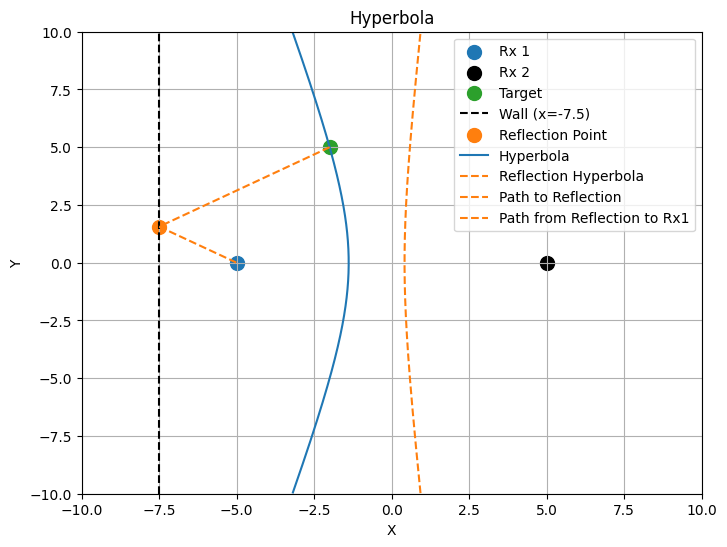

In [ ]:

hyperbola_points = tdoa_hyperbola(Rx1, Rx2, diff_dist, num_points=1000, x_bounds=(-10, 10), y_bounds=(-10, 10))
hyperbola_points_reflection = tdoa_hyperbola(Rx1, Rx2, diff_dist_reflection, num_points=1000, x_bounds=(-10, 10), y_bounds=(-10, 10))

plt.figure(figsize=(8, 6))
plt.scatter(Rx1[0], Rx1[1], color='tab:blue', s=100, label='Rx 1')
plt.scatter(Rx2[0], Rx2[1], color='black', s=100, label='Rx 2')
plt.scatter(Tx[0], Tx[1], color='tab:green', s=100, label='Target')
plt.axvline(x=-7.5, color='black', linestyle='--', label='Wall (x=-7.5)')
plt.scatter(reflection_point[0], reflection_point[1], color='tab:orange', s=100, label='Reflection Point')
# TDOA Hyperbolas
plt.plot(hyperbola_points[0], hyperbola_points[1], color='tab:blue', label='Hyperbola')
plt.plot(hyperbola_points_reflection[0], hyperbola_points_reflection[1], linestyle='--', color='tab:orange', label='Reflection Hyperbola')
# Paths
plt.plot([Tx[0], reflection_point[0]], [Tx[1], reflection_point[1]], color='tab:orange', linestyle='--', label='Path to Reflection')
plt.plot([reflection_point[0], Rx1[0]], [reflection_point[1], Rx1[1]], color='tab:orange', linestyle='--', label='Path from Reflection to Rx1')
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(-20, 10)
plt.ylim(-10, 10)
plt.title('Hyperbola')
plt.legend()
plt.grid(True)
plt.show()